<a href="https://colab.research.google.com/github/sajjaporn-sr/My-coursework/blob/main/SS_Wine_Classification_and_Feature_Selection_using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**: A two-stage classification project using the Random Forest algorithm on the Wine dataset. The project compares model performance between using the full feature set and using the influential features set identified through define threshold to select important features.

**Tools Used**: Python, Pandas, Numpy, Scikit-Learn, Tensorflow, matplotlib, Seaborn.

**Key Learning**: Using 'model.feature_importances_' to identify and select key features that significantly impact the model's predictive power. Using 'SelectFromModel' to select feature that importance score is more than threshold.


In [1]:
from IPython.display import Image
%matplotlib inline

##Reading a wine dataset and partitioning it into a separate training and test set

In [2]:
import numpy as np
import pandas as pd
df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                      'ml/machine-learning-databases/wine/wine.data',
                      header=None)


In [3]:
df_wine.sample(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840
161,3,13.69,3.26,2.54,20.0,107,1.83,0.56,0.50,0.80,5.88,0.96,1.82,680
101,2,12.60,1.34,1.90,18.5,88,1.45,1.36,0.29,1.35,2.45,1.04,2.77,562
32,1,13.68,1.83,2.36,17.2,104,2.42,2.69,0.42,1.97,3.84,1.23,2.87,990
94,2,11.62,1.99,2.28,18.0,98,3.02,2.26,0.17,1.35,3.25,1.16,2.96,345
97,2,12.29,1.41,1.98,16.0,85,2.55,2.50,0.29,1.77,2.90,1.23,2.74,428
80,2,12.00,0.92,2.00,19.0,86,2.42,2.26,0.30,1.43,2.50,1.38,3.12,278
41,1,13.41,3.84,2.12,18.8,90,2.45,2.68,0.27,1.48,4.28,0.91,3.00,1035
33,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
160,3,12.36,3.83,2.38,21.0,88,2.30,0.92,0.50,1.04,7.65,0.56,1.58,520


In [7]:
df_wine.columns = ['Class_label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

df_wine.sample(10)

,Class_label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
28,1,13.87,1.90,2.80,19.4,107,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915
24,1,13.50,1.81,2.61,20.0,96,2.53,2.61,0.28,1.66,3.52,1.12,3.82,845
97,2,12.29,1.41,1.98,16.0,85,2.55,2.50,0.29,1.77,2.90,1.23,2.74,428
53,1,13.77,1.90,2.68,17.1,115,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375
86,2,12.16,1.61,2.31,22.8,90,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495
146,3,13.88,5.04,2.23,20.0,80,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415
19,1,13.64,3.10,2.56,15.2,116,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845
12,1,13.75,1.73,2.41,16.0,89,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320
23,1,12.85,1.60,2.52,17.8,95,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015
112,2,11.76,2.68,2.92,20.0,103,1.75,2.03,0.60,1.05,3.80,1.23,2.50,607


In [8]:
df_wine.shape

(178, 14)

In [9]:
df_wine.columns

Index(['Class_label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

In [10]:
df_wine.describe().T


,count,mean,std,min,25%,50%,75%,max
Class_label,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity of ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [12]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)

##Transform features into standard normal distribution

In [13]:
from sklearn.preprocessing import StandardScaler
stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

##Feature Selection by Random Forest

Random forest with all feature: 100.00%


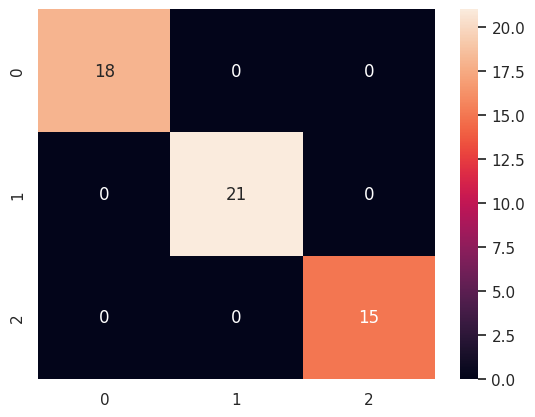

In [17]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns; sns.set_theme()

forest = RandomForestClassifier(n_estimators=50,
                                random_state=42)

forest.fit(X_train_std, y_train)
y_pred = forest.predict(X_test_std)
accuracy = accuracy_score(y_test, y_pred)
print("Random forest with all feature: {:.2f}%".format(accuracy * 100))

ax = sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt="d")

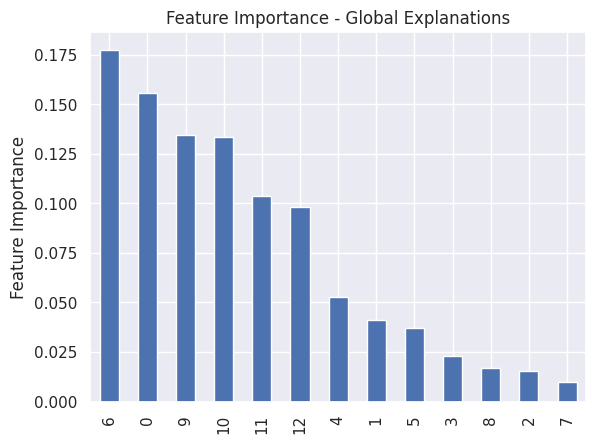

In [18]:
importances = forest.feature_importances_
importances_bar = pd.Series(importances)
importances_bar.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Importance")
plt.title("Feature Importance - Global Explanations")
plt.show()

In [19]:
indices = np.argsort(importances)[::-1]
indices

array([ 6,  0,  9, 10, 11, 12,  4,  1,  5,  3,  8,  2,  7])

In [22]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(forest, threshold=0.1, prefit=True)
X_selected = sfm.transform(X)
print('Number of features that meet this threshold criterion:', X_selected.shape[1])

Number of features that meet this threshold criterion: 5


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)
stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

Random forest with all feature: 100.00%


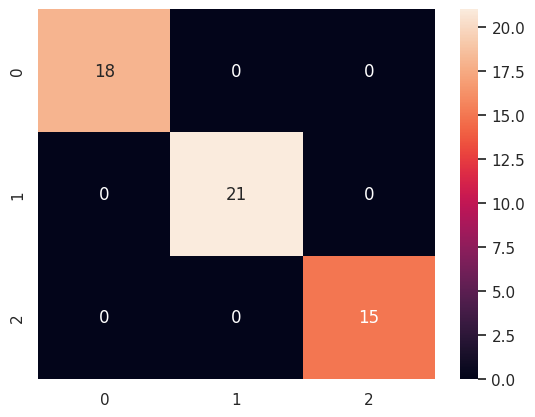

In [25]:
forest = RandomForestClassifier(n_estimators=50,
                                random_state=42)

forest.fit(X_train_std, y_train)
y_pred = forest.predict(X_test_std)
accuracy = accuracy_score(y_test, y_pred)
print("Random forest with all feature: {:.2f}%".format(accuracy * 100))

ax = sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt="d")